In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('data-tbtl/annonimized.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295198 entries, 0 to 295197
Data columns (total 11 columns):
 #   Column                           Non-Null Count   Dtype 
---  ------                           --------------   ----- 
 0   concat('it001',`assignment_id`)  295198 non-null  object
 1   concat('it001',`problem_id`)     295198 non-null  object
 2   concat('it001', username)        295198 non-null  object
 3   is_final                         295198 non-null  int64 
 4   status                           295198 non-null  object
 5   pre_score                        295198 non-null  int64 
 6   coefficient                      295198 non-null  int64 
 7   concat('it001',`language_id`)    295198 non-null  object
 8   created_at                       295198 non-null  object
 9   updated_at                       295198 non-null  object
 10  judgement                        295198 non-null  object
dtypes: int64(3), object(8)
memory usage: 24.8+ MB


In [3]:
# Calculate accepted status based on judgement
df['accepted'] = df['judgement'].apply(lambda x: 1 if '"verdicts":[]' in x else 0)

# Drop unnecessary columns
df = df.drop(columns=["concat('it001',`language_id`)", "updated_at"])

df = df.rename(columns={
    "concat('it001',`problem_id`)": "problem_id",
    "concat('it001', username)": "username",
    "concat('it001',`assignment_id`)" : "assignment_id",
})


df['created_at'] = pd.to_datetime(df['created_at'], 
                                format='%m-%d %H:%M:%S',  # Specify format
                                errors='coerce')             # Handle errors gracefully

min_dates = df.groupby(['problem_id', 'assignment_id'])['created_at'].transform('min')


In [4]:
df['created_at'] = (df['created_at'] - min_dates).dt.total_seconds() / 3600

# Convert score to percentage
df['pre_score'] = df['pre_score'] / 10000 * 100

# Set score to 0 for non-accepted submissions
df.loc[df['accepted'] == 0, 'pre_score'] = 0

df.head()

,assignment_id,problem_id,username,is_final,status,pre_score,coefficient,created_at,judgement,accepted
0,90ce27571176d87961b565d5ef4b3de33ede04ac,789454427dd4097a14749e3dde63346b7a8d3811,ed9eaeb6a707f50154024b24d7efcb874a9795dd,0,SCORE,0.0,100,1.568611,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0...",0
1,90ce27571176d87961b565d5ef4b3de33ede04ac,789454427dd4097a14749e3dde63346b7a8d3811,ed9eaeb6a707f50154024b24d7efcb874a9795dd,0,SCORE,0.0,100,1.612222,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0...",0
2,90ce27571176d87961b565d5ef4b3de33ede04ac,789454427dd4097a14749e3dde63346b7a8d3811,ed9eaeb6a707f50154024b24d7efcb874a9795dd,1,SCORE,100.0,100,1.647778,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0...",1
3,90ce27571176d87961b565d5ef4b3de33ede04ac,bf96fbdc5f499538c3e2bfbec5779c8a14b0a9ff,ed9eaeb6a707f50154024b24d7efcb874a9795dd,1,SCORE,100.0,100,1.969722,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0...",1
4,90ce27571176d87961b565d5ef4b3de33ede04ac,7a6e5ca470ff47c3b5048f240c4738de71010c78,ed9eaeb6a707f50154024b24d7efcb874a9795dd,1,SCORE,100.0,100,2.449167,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0...",1


In [5]:
# Group by username and problem_id and calculate the sum of scores
grouped_df = df.groupby(['username', 'problem_id', 'assignment_id']).agg({'pre_score': 'max', 'accepted': 'max', 'created_at' : 'max'}).reset_index()

# Create a total time try for each problem id for each person
grouped_df['total_time_try'] = df.groupby(['username', 'problem_id']).size().reset_index(name='total_time_try')['total_time_try']

df = grouped_df
df['percent'] = df['accepted'] / df['total_time_try']

# Drop assignment_id column
df = df.drop(columns=['assignment_id'])
df.head()

,username,problem_id,pre_score,accepted,created_at,total_time_try,percent
0,00b6dd4fc7eb817e03708c532016ef30ce564a61,008f8e9b0f4fac6b5f188f0dc8d118a8b19aabee,100.0,1,0.828889,1.0,1.000000
1,00b6dd4fc7eb817e03708c532016ef30ce564a61,10ef40cac132f24608f893c45f1452173e00e0b6,100.0,1,0.620833,1.0,1.000000
2,00b6dd4fc7eb817e03708c532016ef30ce564a61,11cff2e1cb6f229a49b9be40225764aa6a38508f,100.0,1,173.191111,1.0,1.000000
3,00b6dd4fc7eb817e03708c532016ef30ce564a61,1d824e02c40fecdae25d89c0357410997dfbf799,100.0,1,1.511389,1.0,1.000000
4,00b6dd4fc7eb817e03708c532016ef30ce564a61,217ba7563116dab9ca8bf00875e14cec255d7525,100.0,1,154.305000,7.0,0.142857


In [6]:
# Create pivot table with pre_score as values
pivot_df = pd.pivot_table(df, 
                         values=['pre_score', 'accepted', 'total_time_try', 'percent', 'created_at'],
                         index='username',
                         columns='problem_id',
                         fill_value=0)

# Display first few rows
pivot_df.columns = ['_'.join(col).strip() for col in pivot_df.columns.values]

In [7]:
pivot_df.head()

,accepted_008f8e9b0f4fac6b5f188f0dc8d118a8b19aabee,accepted_013e2f57867e3ab62d2043beecedade7ea6cf545,accepted_017ff00dd3fe1e6f8297b5061215343742259f6a,accepted_027fd74619cb74676a464759ddfeb06457d80aa4,accepted_028df0dceb107528f66ee892dae5ded64b21d470,accepted_03918d9c6e62e84d631d42f35278e466e91fac05,accepted_03aa28c6280c37962abcc11612cbbe14e3e25756,accepted_04681b16ae128da4be6bcdf7ae98b4c294ed20b5,accepted_04f7906119d04c0368807ca0ca9a4d7a5293cbfe,accepted_06c8bcdd51eda3b976f73de08b2efdf5eae25e2a,...,total_time_try_fc32b6966d3797fd8b485d8f61fe83e1dd62abf6,total_time_try_fc63e9a7e711717cbd2d94f2056830b3cc39e6d4,total_time_try_fc75f9dbe4c216b9d90808df4c6e5facb7212b8b,total_time_try_fd5acaa23983406b9aa2da5265639ff1b54d0794,total_time_try_fd66e6bd78793b313c05943e82c744e61aa215cf,total_time_try_fd761cbe57c9f2eea1cdebc5cc708fafa95dda40,total_time_try_fe90c40607a0d2caacfc1b1083de4e3f6a6c9c10,total_time_try_ff75347a4671d84aba7db89af5a1de668661f692,total_time_try_ffbf74d579d9fef54254fb6ee0a579d26b052ecc,total_time_try_ffd176ba6494736bdff4d845f6d0c833a304b8de
username,,,,,,,,,,,,,,,,,,,,,
00b6dd4fc7eb817e03708c532016ef30ce564a61,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,3.0,0.0,0.0
00bef8afee8f3c595d535c9c03c490cac1a4f021,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.0,0.0,0.0
01122b3ef7e59b84189e65985305f575d6bdf83c,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,6.0,0.0,0.0
0134f9f410c65ad0e8c2254a7e9288670e02a183,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,2.0,3.0,0.0,0.0
013de369c439ab0ead8aa7da64423aa395a8be39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
df = pivot_df
th = pd.read_csv('public_it001/th-public.csv')
th = th.rename(columns={
    "hash": "username",
})
th.head()

,username,TH
0,00b6dd4fc7eb817e03708c532016ef30ce564a61,5
1,00bef8afee8f3c595d535c9c03c490cac1a4f021,8.5
2,01122b3ef7e59b84189e65985305f575d6bdf83c,7
3,013de369c439ab0ead8aa7da64423aa395a8be39,10
4,014c59c6433fd764a0b08de6ffeb757eaf60aa73,6


In [9]:
test = pd.merge(df, th, on='username', how='left', indicator=True)
test = test[test['_merge'] == 'left_only'].drop(columns=['_merge'])
test.head()

,username,accepted_008f8e9b0f4fac6b5f188f0dc8d118a8b19aabee,accepted_013e2f57867e3ab62d2043beecedade7ea6cf545,accepted_017ff00dd3fe1e6f8297b5061215343742259f6a,accepted_027fd74619cb74676a464759ddfeb06457d80aa4,accepted_028df0dceb107528f66ee892dae5ded64b21d470,accepted_03918d9c6e62e84d631d42f35278e466e91fac05,accepted_03aa28c6280c37962abcc11612cbbe14e3e25756,accepted_04681b16ae128da4be6bcdf7ae98b4c294ed20b5,accepted_04f7906119d04c0368807ca0ca9a4d7a5293cbfe,...,total_time_try_fc63e9a7e711717cbd2d94f2056830b3cc39e6d4,total_time_try_fc75f9dbe4c216b9d90808df4c6e5facb7212b8b,total_time_try_fd5acaa23983406b9aa2da5265639ff1b54d0794,total_time_try_fd66e6bd78793b313c05943e82c744e61aa215cf,total_time_try_fd761cbe57c9f2eea1cdebc5cc708fafa95dda40,total_time_try_fe90c40607a0d2caacfc1b1083de4e3f6a6c9c10,total_time_try_ff75347a4671d84aba7db89af5a1de668661f692,total_time_try_ffbf74d579d9fef54254fb6ee0a579d26b052ecc,total_time_try_ffd176ba6494736bdff4d845f6d0c833a304b8de,TH
3,0134f9f410c65ad0e8c2254a7e9288670e02a183,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,2.0,3.0,0.0,0.0,NaN
20,035f97702f2c01d26ab1fae8f39ea2f98a0caa3c,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,0.0,0.0,0.0,0.0,1.0,7.0,0.0,0.0,NaN
68,0aaebc88f6106684d6993c156104c1ef36cf94e0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,NaN
80,0bf111a9caedf02804f6991792490e63bc21058a,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,NaN
120,12887fd9a4df4ba9b88a71f3fb1d2502a75995dd,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,NaN


In [10]:
merged_df = pd.merge(th, df, on='username', how='inner')
merged_df['TH'] = (merged_df['TH']
                   .replace(['\xa0', ''], np.nan)  # Replace invalid values with NaN
                   .astype(float))                 # Convert to numeric

# Calculate mean and fill NaN values
mean_th = merged_df['TH'].mean()
merged_df['TH'] = merged_df['TH'].fillna(mean_th)
# Display first few rows
df = merged_df
df.head()

,username,TH,accepted_008f8e9b0f4fac6b5f188f0dc8d118a8b19aabee,accepted_013e2f57867e3ab62d2043beecedade7ea6cf545,accepted_017ff00dd3fe1e6f8297b5061215343742259f6a,accepted_027fd74619cb74676a464759ddfeb06457d80aa4,accepted_028df0dceb107528f66ee892dae5ded64b21d470,accepted_03918d9c6e62e84d631d42f35278e466e91fac05,accepted_03aa28c6280c37962abcc11612cbbe14e3e25756,accepted_04681b16ae128da4be6bcdf7ae98b4c294ed20b5,...,total_time_try_fc32b6966d3797fd8b485d8f61fe83e1dd62abf6,total_time_try_fc63e9a7e711717cbd2d94f2056830b3cc39e6d4,total_time_try_fc75f9dbe4c216b9d90808df4c6e5facb7212b8b,total_time_try_fd5acaa23983406b9aa2da5265639ff1b54d0794,total_time_try_fd66e6bd78793b313c05943e82c744e61aa215cf,total_time_try_fd761cbe57c9f2eea1cdebc5cc708fafa95dda40,total_time_try_fe90c40607a0d2caacfc1b1083de4e3f6a6c9c10,total_time_try_ff75347a4671d84aba7db89af5a1de668661f692,total_time_try_ffbf74d579d9fef54254fb6ee0a579d26b052ecc,total_time_try_ffd176ba6494736bdff4d845f6d0c833a304b8de
0,00b6dd4fc7eb817e03708c532016ef30ce564a61,5.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,3.0,0.0,0.0
1,00bef8afee8f3c595d535c9c03c490cac1a4f021,8.5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.0,0.0,0.0
2,01122b3ef7e59b84189e65985305f575d6bdf83c,7.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,6.0,0.0,0.0
3,013de369c439ab0ead8aa7da64423aa395a8be39,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,014c59c6433fd764a0b08de6ffeb757eaf60aa73,6.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,5.0,0.0,0.0,0.0,0.0,2.0,17.0,0.0,0.0


In [11]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression
import matplotlib.pyplot as plt

numeric_features = df.select_dtypes(include=[np.number])
X = numeric_features.drop(['TH', 'username'] if 'username' in numeric_features.columns else ['TH'], axis=1)
y = df['TH']

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Calculate MI scores
mi_scores = mutual_info_regression(X_scaled, y, random_state=42, n_neighbors=5)

# Create and sort importance dataframe
mi_df = pd.DataFrame({
    'Feature': X.columns,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)


print("\nMutual Information Scores:")
print(mi_df)


Mutual Information Scores:
                                                Feature  MI_Score
876   created_at_e45544a7f81f62662e7bda91e2edbd867d7...  0.133410
1692  pre_score_a02511bb9be2f9790dffd3612693dce4e516...  0.126368
763   created_at_a692996453485b2622812e33a54c42f42ad...  0.115729
532   created_at_226fa4527608ac43537095f4f56dcdd43b3...  0.111276
851   created_at_d5c81f9c72cad69c9686dc0ea694b61e15d...  0.110824
...                                                 ...       ...
1246   percent_ac6882be10fa996e8426680b09625dc2b16d4699  0.000000
1634  pre_score_8262a32a2ccdfb446f5d9036a11990ca4e49...  0.000000
1638  pre_score_86162ea4172cb1db75040905b3946eff46c5...  0.000000
1639  pre_score_86d647b91e0d9c3278bc9273921872820aff...  0.000000
1256   percent_b31df36d4dbdf78290b915f20595a9f7baced9c3  0.000000

[2345 rows x 2 columns]



Number of features with MI score > alpha: 1573

Features with MI score > alpha:
                                                Feature  MI_Score
876   created_at_e45544a7f81f62662e7bda91e2edbd867d7...  0.133410
1692  pre_score_a02511bb9be2f9790dffd3612693dce4e516...  0.126368
763   created_at_a692996453485b2622812e33a54c42f42ad...  0.115729
532   created_at_226fa4527608ac43537095f4f56dcdd43b3...  0.111276
851   created_at_d5c81f9c72cad69c9686dc0ea694b61e15d...  0.110824
...                                                 ...       ...
1389   percent_f823c4d2478a057828c3d750a01eb7635f3034f8  0.001081
1821  pre_score_e7ef5d00764884f7399d2beaed6ecf3e32f9...  0.001075
417   accepted_e8b67e20b62d0aa42092538a5983c71604bd40e9  0.001054
2331  total_time_try_f94b564a25b2c807fc08b975e2aabd9...  0.001040
399   accepted_e15c8a2daa86159f2cd7e7ee2deb96cc7e2f95a5  0.001019

[1573 rows x 2 columns]


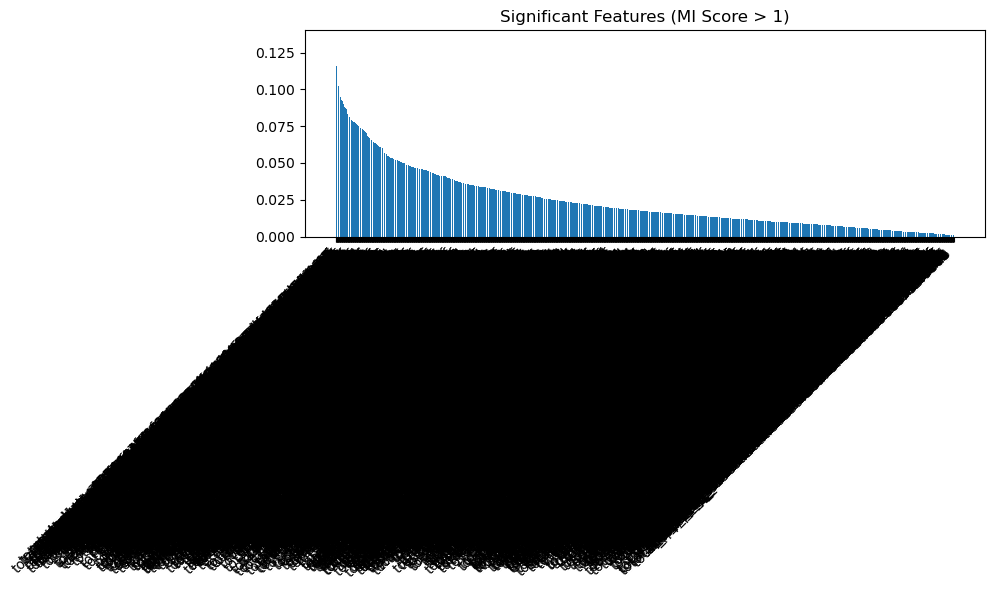

In [12]:
# Get features with MI score > alpha
significant_features = mi_df[mi_df['MI_Score'] > 0.001]

# Count significant features
print(f"\nNumber of features with MI score > alpha: {len(significant_features)}")

# Display significant features
print("\nFeatures with MI score > alpha:")
print(significant_features)

# Visualize significant features
plt.figure(figsize=(10, 6))
plt.bar(significant_features['Feature'], significant_features['MI_Score'])
plt.xticks(rotation=45, ha='right')
plt.title('Significant Features (MI Score > 1)')
plt.tight_layout()
plt.show()

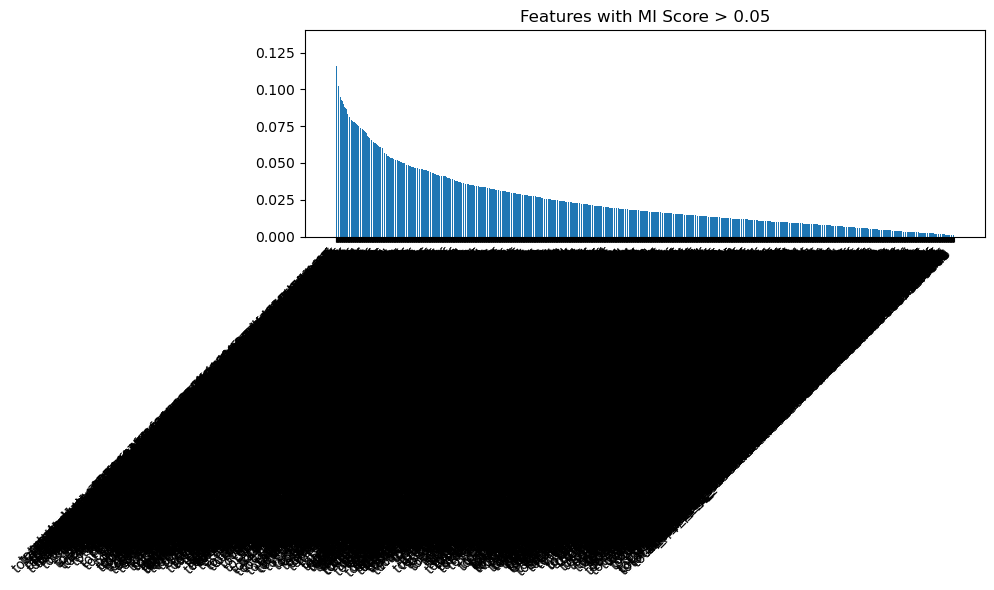


Number of remaining features: 1573

Remaining features and their MI scores:
                                                Feature  MI_Score
876   created_at_e45544a7f81f62662e7bda91e2edbd867d7...  0.133410
1692  pre_score_a02511bb9be2f9790dffd3612693dce4e516...  0.126368
763   created_at_a692996453485b2622812e33a54c42f42ad...  0.115729
532   created_at_226fa4527608ac43537095f4f56dcdd43b3...  0.111276
851   created_at_d5c81f9c72cad69c9686dc0ea694b61e15d...  0.110824
...                                                 ...       ...
1389   percent_f823c4d2478a057828c3d750a01eb7635f3034f8  0.001081
1821  pre_score_e7ef5d00764884f7399d2beaed6ecf3e32f9...  0.001075
417   accepted_e8b67e20b62d0aa42092538a5983c71604bd40e9  0.001054
2331  total_time_try_f94b564a25b2c807fc08b975e2aabd9...  0.001040
399   accepted_e15c8a2daa86159f2cd7e7ee2deb96cc7e2f95a5  0.001019

[1573 rows x 2 columns]


In [13]:
# Filter features with MI score > 0.05
significant_features = mi_df[mi_df['MI_Score'] > 0.001]

# Get list of features to keep
features_to_keep = list(significant_features['Feature'])

# Drop low importance features from original scaled dataset
X_filtered = X_scaled[features_to_keep]

# Update visualization for remaining features
plt.figure(figsize=(10, 6))
plt.bar(significant_features['Feature'], significant_features['MI_Score'])
plt.xticks(rotation=45, ha='right')
plt.title('Features with MI Score > 0.05')
plt.tight_layout()
plt.show()

print(f"\nNumber of remaining features: {len(features_to_keep)}")
print("\nRemaining features and their MI scores:")
print(significant_features)

In [14]:
import pandas as pd
from sklearn.ensemble import VotingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import lightgbm as lgb
from catboost import CatBoostRegressor

# Assuming X_filtered and df['TH'] are defined earlier in the script
# Replace these placeholders with your actual dataset
X = X_filtered  # Ensure X_filtered is properly prepared
y = df['TH']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize models
lgb_model = lgb.LGBMRegressor(random_state=42, device='gpu', gpu_platform_id=0, gpu_device_id=0, verbose=-1,
    subsample=0.8,
    n_estimators=100,
    max_depth=5,
    learning_rate=0.05,
    num_leaves=70
)
catboost_model = CatBoostRegressor(random_state=42, silent=True,
    iterations=200,
    depth=5,
    learning_rate=0.05
)

voting_regressor = VotingRegressor(estimators=[
    ('lgb', lgb_model),
    ('catboost', catboost_model)
])

voting_regressor.fit(X, y)

# Make predictions
predictions = voting_regressor.predict(X_test)
train_pred = voting_regressor.predict(X_train)

# Calculate metrics
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

mse_train = mean_squared_error(y_train, train_pred)
r2_train = r2_score(y_train, train_pred)

# Output results
print(f'Optimized Voting Regressor with LightGBM and CatBoost using GPU')
print(f'Mean Squared Error: {mse:.4f}')
print(f'R2 Score: {r2:.4f}')
print(f'Mean Squared Error Train: {mse_train:.4f}')
print(f'R2 Score Train: {r2_train:.4f}')

Optimized Voting Regressor with LightGBM and CatBoost using GPU
Mean Squared Error: 1.6306
R2 Score: 0.7057
Mean Squared Error Train: 1.1401
R2 Score Train: 0.7457


In [15]:
numeric_features = test.select_dtypes(include=[np.number])
X = numeric_features
y = df['TH']


# Normalize features
#X.drop(columns=['TH'], inplace=True)
X_scaled = scaler.transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
features_to_keep = list(significant_features['Feature'])

# Drop low importance features from original scaled dataset
X_filtered = X_scaled[features_to_keep]

test['TH'] = voting_regressor.predict(X_filtered)
test = test[['username', 'TH']]
test.head()

,username,TH
3,0134f9f410c65ad0e8c2254a7e9288670e02a183,5.121990
20,035f97702f2c01d26ab1fae8f39ea2f98a0caa3c,5.501152
68,0aaebc88f6106684d6993c156104c1ef36cf94e0,5.401941
80,0bf111a9caedf02804f6991792490e63bc21058a,7.779418
120,12887fd9a4df4ba9b88a71f3fb1d2502a75995dd,7.888819


In [16]:
test['TH'] = pd.to_numeric(test['TH'], errors='coerce')
test['TH'] = test['TH'].astype(float)
test['TH'] = test['TH'].round(2)

test.head()

,username,TH
3,0134f9f410c65ad0e8c2254a7e9288670e02a183,5.12
20,035f97702f2c01d26ab1fae8f39ea2f98a0caa3c,5.50
68,0aaebc88f6106684d6993c156104c1ef36cf94e0,5.40
80,0bf111a9caedf02804f6991792490e63bc21058a,7.78
120,12887fd9a4df4ba9b88a71f3fb1d2502a75995dd,7.89


In [17]:
test.to_csv('updated_test.csv', index=False)